In [1]:
import pandas as pd
import numpy as np
import xml.etree.ElementTree as ET


# Parse XML
tree = ET.parse("data/cante2midi_meta.xml")   # or ET.fromstring(xml_string)
root = tree.getroot()

rows = []

for track in root.findall("track"):
    row = {}
    
    row["id"] = track.get("id")
    
    source = track.find("source")
    row["anthology"] = source.findtext("anthology")
    row["cd_no"] = source.findtext("cd-no")
    row["track_no"] = source.findtext("track-no")
    
    meta = track.find("meta")
    row["artist"] = meta.findtext("artist")
    row["title"] = meta.findtext("title")
    row["style"] = meta.findtext("style")
    row["duration_min"] = meta.findtext("duration_min")
    row["duration_sec"] = meta.findtext("duration_sec")
    
    row["musicBrainz"] = track.findtext("musicBrainz")
    
    rows.append(row)

cante2midi_meta = pd.DataFrame(rows)


cante2midi_meta['id']=cante2midi_meta['id'].astype('Int64')
cante2midi_meta.head()


,id,anthology,cd_no,track_no,artist,title,style,duration_min,duration_sec,musicBrainz
0,1,Magna antología del cante flamenco,6,6,Gabriel Moreno,Yo no te dao motivos,Tiento de La Niña de los Peines,4,8,f1e14261-4e57-485a-a8f3-87892f19b4c4
1,2,Magna antología del cante flamenco,8,8,Bernardo el de los lobitos,Los peces mueran de pena,Malagueña de Gayarrito,3,10,a7772f17-6b79-485f-a61c-7a224c90191c
2,3,Magna antología del cante flamenco,7,15,Bernardo el de los lobitos,Por las trenzas de tu pelo,Malagueñita de El Canario,3,15,dc6a38ce-a357-4f3a-a853-5b85f9b8fe6f
3,4,Magna antología del cante flamenco,5,17,Angel de Alora,Los caminos estan muy malos,Cantes del piyayo (Tango de Málaga),3,10,e8863f01-8cfb-4a22-b070-65cfa44c0e6c
4,5,Magna antología del cante flamenco,2,17,Antonio Mairena,Verguenza,Siguiriyas de Cadiz,1,46,ab797c04-6764-4c71-86fd-a3cdfbd98975


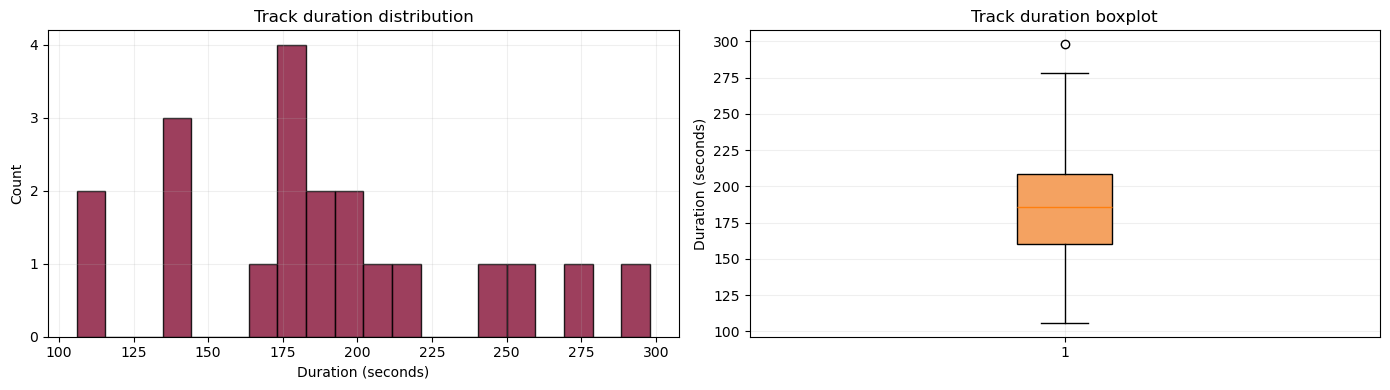

count     20.000000
mean     189.700000
std       50.694233
min      106.000000
25%      160.500000
50%      186.000000
75%      208.500000
max      298.000000
Name: duration_total_sec, dtype: float64

In [3]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Build total duration in seconds (robust to strings/missing values)
cante2midi_meta["duration_min"] = pd.to_numeric(cante2midi_meta["duration_min"], errors="coerce")
cante2midi_meta["duration_sec"] = pd.to_numeric(cante2midi_meta["duration_sec"], errors="coerce")
cante2midi_meta["duration_total_sec"] = (
    cante2midi_meta["duration_min"].fillna(0) * 60
    + cante2midi_meta["duration_sec"].fillna(0)
)

dur = cante2midi_meta["duration_total_sec"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(dur, bins=20, color="#8c1d40", alpha=0.85, edgecolor="black")
axes[0].set_title("Track duration distribution")
axes[0].set_xlabel("Duration (seconds)")
axes[0].set_ylabel("Count")
axes[0].yaxis.set_major_locator(MaxNLocator(integer=True))
axes[0].grid(alpha=0.2)

# Boxplot
axes[1].boxplot(dur, vert=True, patch_artist=True, boxprops={"facecolor": "#f4a261"})
axes[1].set_title("Track duration boxplot")
axes[1].set_ylabel("Duration (seconds)")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

dur.describe()